# Jupyter Notebook: Data cleaning

## Step 1: Install Required Libraries

First, ensure you have the necessary libraries installed. You can install them using the following command:

`pip install pandas numpy seaborn matplotlib`

In [101]:
# Imports
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## Step 2: Reading the data and removing missing values
Reading the training data

In [102]:
data_path = Path("titanic.csv")
train_df = pd.read_csv(data_path)
train_df.head(5)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Determining how many missing values each column contains. 

In [103]:
def report_missing_values(df: pd.DataFrame) -> None:
    """Print missing values count and percentage for each column."""
    for column in df.columns:
        missing_count = df[column].isnull().sum()
        total_count = len(df[column])
        missing_percentage = (missing_count / total_count) * 100
        print(f"{column} - {missing_count}, {missing_percentage:.2f}%")


report_missing_values(train_df)


PassengerId - 0, 0.00%
Survived - 0, 0.00%
Pclass - 0, 0.00%
Name - 0, 0.00%
Sex - 0, 0.00%
Age - 177, 19.84%
SibSp - 0, 0.00%
Parch - 0, 0.00%
Ticket - 0, 0.00%
Fare - 0, 0.00%
Cabin - 688, 77.13%
Embarked - 2, 0.22%


* Age has ~20% missing values. This will require handling.
* Cabin has ~77% missing values and might be excluded from analysis.
* Embarked has a small proportion of missing values. This will require handling.

Filling missing values for 'age' with the median. The median is used here instead of the mean because it is less affected by outliers. The 'age' column might have extreme values (very young or very old passengers), and the median provides a more robust measure.

In [104]:
train_df["Age"] = train_df["Age"].fillna(train_df["Age"].median())


Filling missing values for 'Embarked' with the mode.
The 'Embarked' column contains categorical data. Using the mode (most frequent value) ensures that the imputed value makes sense contextually.

In [105]:
train_df["Embarked"] = train_df["Embarked"].fillna(train_df["Embarked"].mode()[0])


Dropping 'Cabin' due to a large number of missing values
The 'Cabin' column has too many missing values to be useful for analysis. Dropping it simplifies the dataset.

In [106]:
train_df = train_df.drop(columns=["Cabin"])


Let's make sure that there are no more missing values. 

In [107]:
report_missing_values(train_df)


PassengerId - 0, 0.00%
Survived - 0, 0.00%
Pclass - 0, 0.00%
Name - 0, 0.00%
Sex - 0, 0.00%
Age - 0, 0.00%
SibSp - 0, 0.00%
Parch - 0, 0.00%
Ticket - 0, 0.00%
Fare - 0, 0.00%
Embarked - 0, 0.00%


## Step 3: Visualizing the data



Text(0.5, 1.0, 'Percentage of Passengers Who Survived vs Did Not Survive')

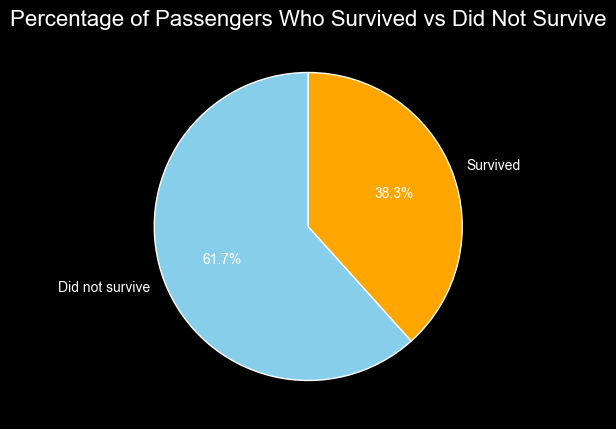

In [108]:
fig3, ax3 = plt.subplots(figsize=(8, 5))
survival_percentages = train_df["Survived"].value_counts(normalize=True) * 100
ax3.pie(
    survival_percentages,
    labels=["Did not survive", "Survived"],
    autopct="%1.1f%%",
    colors=["skyblue", "orange"],
    startangle=90,
)
ax3.set_title("Percentage of Passengers Who Survived vs Did Not Survive", fontsize=16)


Shows survival rate...

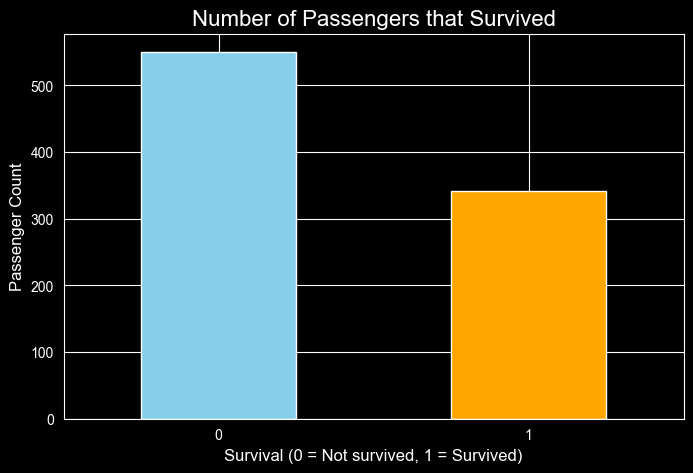

In [109]:
# Plot number of passengers that survived
fig1, ax1 = plt.subplots(figsize=(8, 5))
overall_survival_counts = train_df["Survived"].value_counts(sort=False)
overall_survival_counts.plot(kind="bar", color=["skyblue", "orange"], ax=ax1)
ax1.set_title("Number of Passengers that Survived", fontsize=16)
ax1.set_xlabel("Survival (0 = Not survived, 1 = Survived)", fontsize=12)
ax1.set_ylabel("Passenger Count", fontsize=12)
ax1.tick_params(axis="x", rotation=0)


Shows survival rate...

We are going to do a bar plot to show if survival rates differ between genders, which can reveal trends or inequalities in survival.

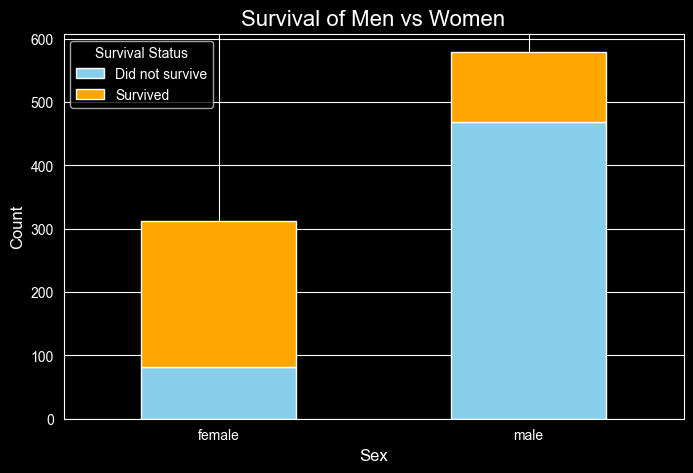

In [110]:
# Group by 'Sex' and 'Survived', then count occurrences
survival_counts = train_df.groupby(["Sex", "Survived"]).size().unstack()

# Plot a bar chart for survival by gender
fig2, ax2 = plt.subplots(figsize=(8, 5))
survival_counts.plot(kind="bar", stacked=True, color=["skyblue", "orange"], ax=ax2)
ax2.set_title("Survival of Men vs Women", fontsize=16)
ax2.set_xlabel("Sex", fontsize=12)
ax2.set_ylabel("Count", fontsize=12)
ax2.legend(["Did not survive", "Survived"], title="Survival Status")
ax2.tick_params(axis="x", rotation=0)


It is apparent that females had a much higher survival rate, this is probably due to most men sacrificing their spot on lifeboats in exchange for the women, as during the societal standards during when the titanic sank. Furthermore it is also likely that men also attempted to save women by returning back to get their lovers, wives, daughters, etc. which would have further reduced their chances of survival.

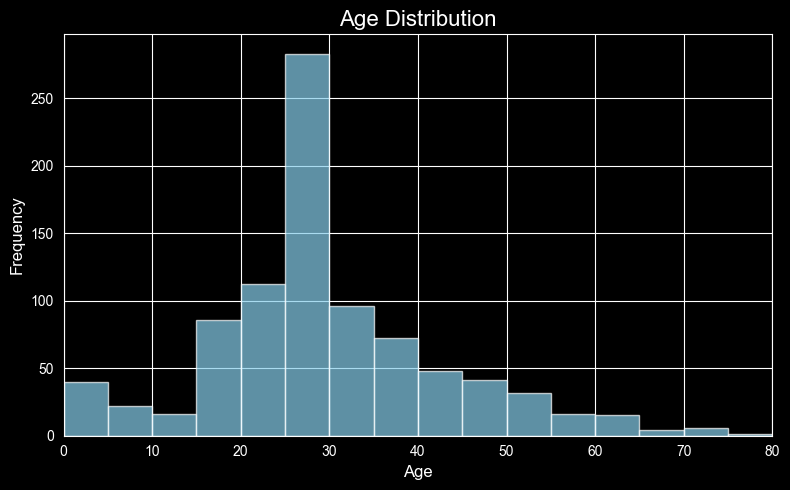

In [114]:
# Shared bins keep both histograms aligned and avoid off-center appearance.
age_bins = list(range(0, 85, 5))

fig4, ax4 = plt.subplots(figsize=(8, 5))
train_df["Age"].plot(kind="hist", bins=age_bins, alpha=0.7, color="skyblue", ax=ax4)
ax4.set_title("Age Distribution", fontsize=16)
ax4.set_xlabel("Age", fontsize=12)
ax4.set_ylabel("Frequency", fontsize=12)
ax4.set_xlim(0, 80)
ax4.set_xticks(range(0, 81, 10))
plt.tight_layout()


Disregarding the scew in the middle due to the median, it is also apparent that most passenges on the ship is between the age of 10 and 40, which is due to the fact that most passengers likely brought along their partners, therefore adding to the number of individuals in that population. Furthermore during that time, the average life span was about 50-60 years therefore highly restricting the amount of people that were to be older than that.

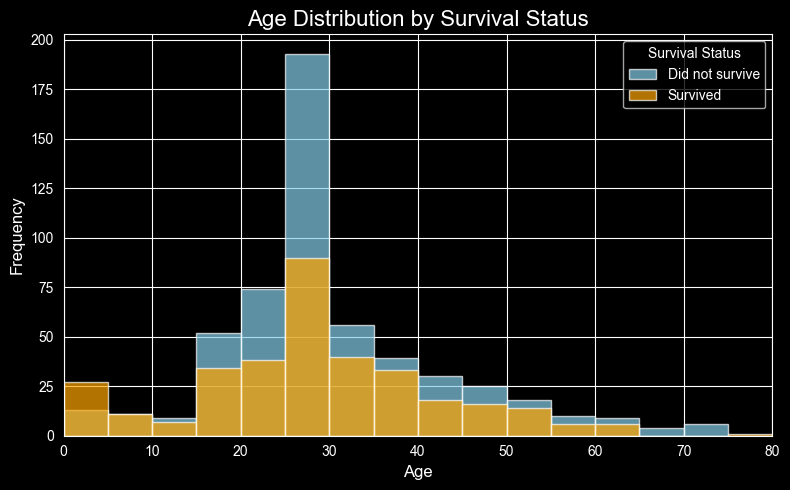

In [124]:
fig5, ax5 = plt.subplots(figsize=(8, 5))
train_df[train_df["Survived"] == 0]["Age"].plot(
    kind="hist", bins=age_bins, alpha=0.7, color="skyblue", ax=ax5
)
train_df[train_df["Survived"] == 1]["Age"].plot(
    kind="hist", bins=age_bins, alpha=0.7, color="orange", ax=ax5
)
ax5.set_title("Age Distribution by Survival Status", fontsize=16)
ax5.legend(["Did not survive", "Survived"], title="Survival Status")
ax5.set_xlabel("Age", fontsize=12)
ax5.set_ylabel("Frequency", fontsize=12)
ax5.set_xlim(0, 80)
ax5.set_xticks(range(0, 81, 10))
plt.tight_layout()


To begin, the medium filling we did for the missing and outlier data has influenced our graph, therefore at the medium age from 25-30 has spiked up to significantly more than the rest. This is due to the extreme and missing data still having the data for whether they survived or not. Furthmore, it is apparant that below 10, there is an high amount of survivors, signifcantly outpacing those who died. In contrast, basically noone above 65 survived, this is a likely due to their advanced age that influenced how likely they were able to survive not only the cold and harsh conditions but also escape in time.

Boxplots for ages of survivors and non-survivors

Text(0, 0.5, 'Age')

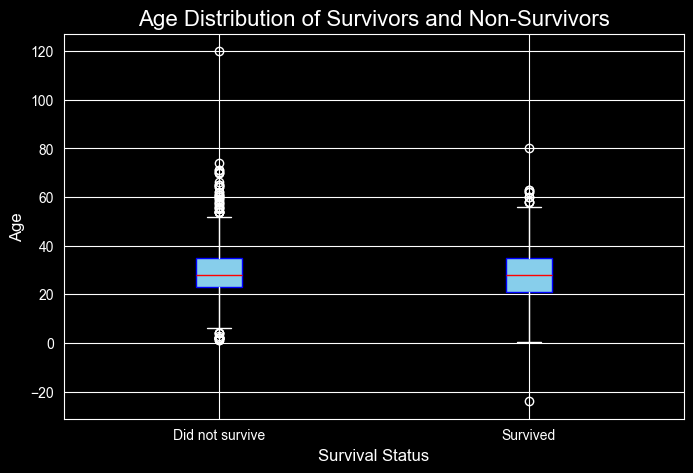

In [123]:
fig7, ax7 = plt.subplots(figsize=(8, 5))
survived_ages = [
    train_df[train_df["Survived"] == 0]["Age"],
    train_df[train_df["Survived"] == 1]["Age"],
]
ax7.boxplot(
    survived_ages,
    tick_labels=["Did not survive", "Survived"],
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", color="blue"),
    medianprops=dict(color="red"),
)
ax7.set_title("Age Distribution of Survivors and Non-Survivors", fontsize=16)
ax7.set_xlabel("Survival Status", fontsize=12)
ax7.set_ylabel("Age", fontsize=12)


Looking at the boxplot, first thing that is noticed is that q1

## Investigation tasks

**Task 1**: a visualization alone is not inherently valuable, its true usefulness lies in the insights we can extract from it. Based on the visualizations provided in Step 3, analyse and interpret each one, focusing on how different features may influence (if they do) the likelihood of survival on the Titanic. For each graph, provide at least two insightful sentences that explain the observed trends and their potential impact on survival rates.

<span style="color:red">(6 marks)</span>

<span style="color:red">Your answer goes here</span>

**Task 2**: determine and justify which type of graph would be most effective in analyzing the correlation between passenger class and the likelihood of survival on the Titanic. 

<span style="color:red">(2 marks)</span>

<span style="color:red">Your answer goes here</span>

**Task 3**: ceate the specified graph to analyze the correlation between passenger class and the likelihood of survival on the Titanic. You may use AI tools to generate the code for visualization, but the interpretation of the results should be your own.

<span style="color:red">(2 marks)</span>

<span style="color:red">Your answer goes here</span>

**Extension 1**: Research scatter plots and treemap charts, explaining their purpose and how they visualize data. Provide one example of how each type of chart could be effectively used with the Titanic dataset to gain insights. Additionally, provide another real-world example where each chart would be useful for a different type of dataset.

<span style="color:red">(1 mark)</span>

<span style="color:red">Your answer goes here</span>

**Bonus**: create a scatter plot and a treemap using the Titanic dataset, then analyse and interpret the results. Explain the insights each visualization provides, including any trends, patterns, or relationships observed in the data.

<span style="color:red">(1 mark)</span>

<span style="color:red">Your answer goes here</span>